In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [2]:
import matplotlib.pyplot as plt
import re



In [3]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
  Using cached nltk-3.9.2-py3-none-any.whl.metadata (3.2 kB)
Using cached nltk-3.9.2-py3-none-any.whl (1.5 MB)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics

In [5]:
df = pd.read_csv("/Users/shouryarghyapatra/Downloads/Sheet_1.csv")
df

,response_id,class,response_text,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,response_1,not_flagged,I try and avoid this sort of conflict,NaN,NaN,NaN,NaN,NaN
1,response_2,flagged,Had a friend open up to me about his mental ad...,NaN,NaN,NaN,NaN,NaN
2,response_3,flagged,I saved a girl from suicide once. She was goin...,NaN,NaN,NaN,NaN,NaN
3,response_4,not_flagged,i cant think of one really...i think i may hav...,NaN,NaN,NaN,NaN,NaN
4,response_5,not_flagged,Only really one friend who doesn't fit into th...,,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
75,response_76,not_flagged,"Now that I've been through it, although i'm no...",NaN,NaN,NaN,NaN,NaN
76,response_77,flagged,when my best friends mom past away from od'ing...,NaN,NaN,NaN,NaN,NaN
77,response_78,not_flagged,As a camp counselor I provide stability in kid...,NaN,NaN,NaN,NaN,NaN
78,response_79,flagged,My now girlfriend used to have serious addicti...,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   response_id    80 non-null     object 
 1   class          80 non-null     object 
 2   response_text  80 non-null     object 
 3   Unnamed: 3     2 non-null      object 
 4   Unnamed: 4     0 non-null      float64
 5   Unnamed: 5     1 non-null      object 
 6   Unnamed: 6     0 non-null      float64
 7   Unnamed: 7     1 non-null      object 
dtypes: float64(2), object(6)
memory usage: 5.1+ KB


In [7]:
df.describe()

,Unnamed: 4,Unnamed: 6
count,0.0,0.0
mean,NaN,NaN
std,NaN,NaN
min,NaN,NaN
25%,NaN,NaN
50%,NaN,NaN
75%,NaN,NaN
max,NaN,NaN


In [8]:
df.dtypes

response_id       object
class             object
response_text     object
Unnamed: 3        object
Unnamed: 4       float64
Unnamed: 5        object
Unnamed: 6       float64
Unnamed: 7        object
dtype: object

In [9]:
df.shape

(80, 8)

In [10]:
df.columns

Index(['response_id', 'class', 'response_text', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7'],
      dtype='object')

In [11]:
df.isnull().sum()

response_id       0
class             0
response_text     0
Unnamed: 3       78
Unnamed: 4       80
Unnamed: 5       79
Unnamed: 6       80
Unnamed: 7       79
dtype: int64

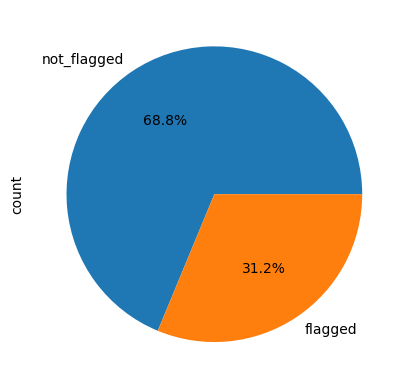

In [12]:
df['class'].value_counts().plot(kind='pie', autopct = '%1.1f%%')
plt.show()

In [13]:
data = df[['class', 'response_text']]
data.head()

,class,response_text
0,not_flagged,I try and avoid this sort of conflict
1,flagged,Had a friend open up to me about his mental ad...
2,flagged,I saved a girl from suicide once. She was goin...
3,not_flagged,i cant think of one really...i think i may hav...
4,not_flagged,Only really one friend who doesn't fit into th...


In [14]:
data['class'] = data.loc[:,'class'].map({'not_flagged':0, 'flagged':1})
data.head()

,class,response_text
0,0,I try and avoid this sort of conflict
1,1,Had a friend open up to me about his mental ad...
2,1,I saved a girl from suicide once. She was goin...
3,0,i cant think of one really...i think i may hav...
4,0,Only really one friend who doesn't fit into th...


In [15]:
data.response_text[1]

'Had a friend open up to me about his mental addiction to weed and how it was taking over his life and making him depressed'

In [16]:
text_1 = data.response_text [1]
text = re.sub(r"[^a-zA-Z]", " ", text_1)
text = text.lower()
print(text)

had a friend open up to me about his mental addiction to weed and how it was taking over his life and making him depressed


In [17]:
token = text.split()
print(token)

['had', 'a', 'friend', 'open', 'up', 'to', 'me', 'about', 'his', 'mental', 'addiction', 'to', 'weed', 'and', 'how', 'it', 'was', 'taking', 'over', 'his', 'life', 'and', 'making', 'him', 'depressed']


In [18]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/shouryarghyapatra/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/shouryarghyapatra/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/shouryarghyapatra/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [19]:
text = "This is a simple example sentence."

tokens = re.findall(r'\b\w+\b', text.lower())

stop_words = {
    'the','is','a','an','and','or','to','of','in','on','for','with','this','that'
}

filtered = [w for w in tokens if w not in stop_words]

print(filtered)

['simple', 'example', 'sentence']


In [20]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

text = "running runs better studies children"

tokens = re.findall(r'\b\w+\b', text.lower())

filtered = [w for w in tokens if w not in ENGLISH_STOP_WORDS]

print(filtered)

['running', 'runs', 'better', 'studies', 'children']


In [21]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

description_list = []

for description in data.response_text:
    # keep only letters
    description = re.sub(r"[^a-zA-Z]", " ", description).lower()
    
    # tokenize
    words = description.split()
    
    # remove stopwords
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    
    # rejoin
    description_list.append(" ".join(words))


In [22]:
def simple_lemmatize(word):
    if word.endswith("ies"):
        return word[:-3] + "y"
    if word.endswith("ing") and len(word) > 4:
        return word[:-3]
    if word.endswith("ed") and len(word) > 3:
        return word[:-2]
    if word.endswith("s") and len(word) > 3:
        return word[:-1]
    return word


description_list = []

for description in data.response_text:
    description = re.sub(r"[^a-zA-Z]", " ", description).lower()
    words = description.split()
    words = [simple_lemmatize(w) for w in words if w not in ENGLISH_STOP_WORDS]
    description_list.append(" ".join(words))


In [23]:
description_list[1]

'friend open mental addiction we tak life mak depress'

In [24]:
max_features = 100
count_vectorizer = CountVectorizer(max_features=max_features)
space_matrix = count_vectorizer.fit_transform(description_list).toarray()
top_words = count_vectorizer.get_feature_names_out()
print("Top 100 most used words: {}".format(top_words))


Top 100 most used words: ['addiction' 'advice' 'anxiety' 'ask' 'away' 'bad' 'best' 'better' 'big'
 'bit' 'blow' 'call' 'camp' 'car' 'come' 'comfort' 'day' 'deal'
 'depression' 'did' 'didn' 'don' 'dont' 'end' 'experience' 'fac' 'feel'
 'friend' 'gf' 'girl' 'girlfriend' 'go' 'gone' 'good' 'got' 'grade'
 'happen' 'hav' 'help' 'helpful' 'issue' 'just' 'kid' 'kill' 'know' 'let'
 'lett' 'life' 'like' 'listen' 'little' 'live' 'll' 'look' 'lot' 'make'
 'ne' 'need' 'night' 'offer' 'open' 'past' 'people' 'person' 'personal'
 'pretty' 'problem' 'really' 'relationship' 'say' 'school' 'self' 'severe'
 'shit' 'similar' 'simply' 'sister' 'situation' 'start' 'struggle' 'stuff'
 'suicide' 'support' 'talk' 'tell' 'think' 'time' 'told' 'tough' 'tri'
 'trouble' 'try' 'us' 've' 'want' 'way' 'week' 'went' 'work' 'year']


In [25]:
x = space_matrix
y = data.iloc[:,0].values
x

array([[0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [3, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [26]:
y

array([0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0])

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.25, random_state = 42)

In [28]:
gnb = GaussianNB()

gnb.fit(x_train,y_train)

y_pred = gnb.predict(x_test)
print("Accuracy :",metrics.accuracy_score(y_pred,y_test))


Accuracy : 0.65


In [29]:
pip install keras

Defaulting to user installation because normal site-packages is not writeable
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 1.2 MB/s eta 0:00:00a 0:00:01
Using cached absl_py-2.3.1-py3-none-any.whl (135 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 2.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 2.9 MB/s eta 0:00:00
Using cached namex-0.1.0-py3-none-any.whl (5.9 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
data.columns

Index(['class', 'response_text'], dtype='object')

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Features and labels
X = description_list
y = data['class']

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(x_train_vec, y_train)

# Evaluation
y_pred = model.predict(x_test_vec)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.70      1.00      0.82        14
           1       0.00      0.00      0.00         6

    accuracy                           0.70        20
   macro avg       0.35      0.50      0.41        20
weighted avg       0.49      0.70      0.58        20



In [32]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

In [33]:
from sklearn.svm import LinearSVC

model = LinearSVC(class_weight='balanced')
model.fit(x_train_vec, y_train)

y_pred = model.predict(x_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      1.00      0.82        14
           1       0.00      0.00      0.00         6

    accuracy                           0.70        20
   macro avg       0.35      0.50      0.41        20
weighted avg       0.49      0.70      0.58        20



In [34]:
vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1,2),
    min_df=2
)

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = description_list
y = data['class']

vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1,2),
    min_df=2
)

X_vec = vectorizer.fit_transform(X)


In [36]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

scores = cross_val_score(
    model,
    X_vec,
    y,
    cv=5,
    scoring='f1_macro'
)

print("F1-macro (CV mean):", scores.mean())


F1-macro (CV mean): 0.538875810180158


In [37]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def preprocess_text(text):
    text = re.sub(r"[^a-zA-Z]", " ", text).lower()
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return " ".join(words)


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Features & labels
X = description_list
y = data['class']

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Vectorizer
vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1,2),
    min_df=2
)

x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

# FINAL trained model
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(x_train_vec, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [39]:
new_text = "I do care about anyone's problems and help anyone"

clean_text = preprocess_text(new_text)
X_new = vectorizer.transform([clean_text])

prediction = model.predict(X_new)

print("Predicted class:", prediction[0])


Predicted class: 0


In [40]:
prob = model.predict_proba(X_new)
print("Class probabilities:", prob)

Class probabilities: [[0.62489341 0.37510659]]


In [41]:
data['class'].value_counts()


class
0    55
1    25
Name: count, dtype: int64

In [42]:
data.groupby('class')['response_text'].head(3)


0                I try and avoid this sort of conflict
1    Had a friend open up to me about his mental ad...
2    I saved a girl from suicide once. She was goin...
3    i cant think of one really...i think i may hav...
4    Only really one friend who doesn't fit into th...
6    Roommate when he was going through death and l...
Name: response_text, dtype: object

In [43]:
data.groupby('class')['response_text'].head(3)


0                I try and avoid this sort of conflict
1    Had a friend open up to me about his mental ad...
2    I saved a girl from suicide once. She was goin...
3    i cant think of one really...i think i may hav...
4    Only really one friend who doesn't fit into th...
6    Roommate when he was going through death and l...
Name: response_text, dtype: object

In [93]:
label_map = {
    0: "Supportive / empathetic response",
    1: "Non-supportive / other response"
}

print("Prediction:", label_map[prediction[0]])


Prediction: Supportive / empathetic response
